# Week 6 Jupyter Notebook — Decision Trees and Random Forests


## Objective

This notebook applies Week 6 decision tree and random forest methods to the flight delay classification problem. These models are useful because they can capture nonlinear patterns and interactions without manually creating polynomial or interaction terms.

I compared a deep decision tree, a tuned decision tree, and a random forest. I also used feature importance to identify which variables were most connected to delay prediction.


In [19]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")


## 1. Load the datasets

The main modeling data comes from the Kaggle `train.csv` and `test.csv` files. The BTS `Flight_Delay.csv` file is used as supporting context for 2019 delay causes.

Tree-based models can handle larger samples more easily than RBF SVMs, so this notebook uses a larger sample than Week 5.

In [20]:
# Load data
# Data files are stored in the data folder.

SAMPLE_SIZE = 100000
TEST_SAMPLE_SIZE = 50000
RANDOM_STATE = 42

train = pd.read_csv("data/train.csv", nrows=SAMPLE_SIZE)
test = pd.read_csv("data/test.csv", nrows=TEST_SAMPLE_SIZE)
flight_delay = pd.read_csv("data/Flight_delay.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Flight_Delay shape:", flight_delay.shape)

train.head()


Train shape: (100000, 30)
Test shape: (50000, 30)
Flight_Delay shape: (484551, 29)


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


## 2. Quick EDA

The target variable is `DEP_DEL15`.

- `0` means the flight was not delayed by at least 15 minutes.
- `1` means the flight was delayed by at least 15 minutes.

This is the same binary classification target used in Weeks 4 and 5.

Target counts:
DEP_DEL15
0    81025
1    18975
Name: count, dtype: int64

Target percentage:
DEP_DEL15
0    81.03
1    18.98
Name: proportion, dtype: float64


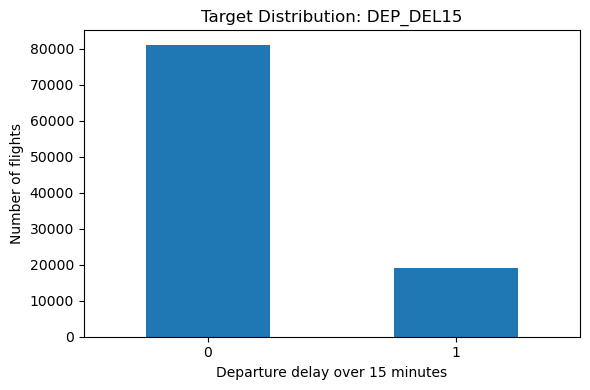


Missing values, top 10:
MONTH                 0
DAY_OF_WEEK           0
DAY_HISTORICAL        0
DEP_AIRPORT_HIST      0
CARRIER_HISTORICAL    0
AWND                  0
TMAX                  0
SNWD                  0
SNOW                  0
PRCP                  0
dtype: int64


In [21]:
target = "DEP_DEL15"

print("Target counts:")
print(train[target].value_counts(dropna=False))

print("\nTarget percentage:")
print((train[target].value_counts(normalize=True, dropna=False) * 100).round(2))

train[target].value_counts().sort_index().plot(kind="bar", figsize=(6, 4))
plt.title("Target Distribution: DEP_DEL15")
plt.xlabel("Departure delay over 15 minutes")
plt.ylabel("Number of flights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nMissing values, top 10:")
print(train.isna().sum().sort_values(ascending=False).head(10))


BTS total delay minutes by cause:
LateAircraftDelay    12915022
CarrierDelay          8440607
NASDelay              6589613
WeatherDelay          1527927
SecurityDelay           39749
dtype: int64


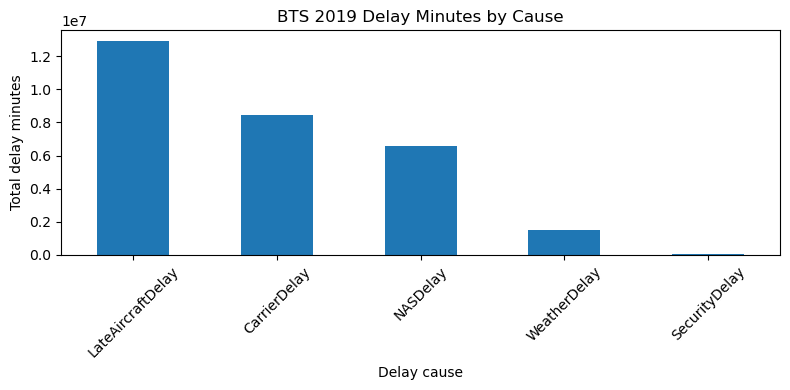

In [22]:
# BTS delay-cause context

bts_delay_cols = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

available_bts_cols = [col for col in bts_delay_cols if col in flight_delay.columns]

if available_bts_cols:
    delay_totals = flight_delay[available_bts_cols].sum().sort_values(ascending=False)

    print("BTS total delay minutes by cause:")
    print(delay_totals)

    delay_totals.plot(kind="bar", figsize=(8, 4))
    plt.title("BTS 2019 Delay Minutes by Cause")
    plt.ylabel("Total delay minutes")
    plt.xlabel("Delay cause")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("BTS delay-cause columns not found. Columns available:")
    print(flight_delay.columns.tolist())


## 3. Select features

Decision trees and random forests can capture nonlinear relationships and interactions between features. I use the same general feature groups from previous weeks:

- flight timing
- route distance
- airport and airline activity
- aircraft information
- weather
- historical delay rates
- categorical airline, airport, and time block information

Unlike logistic regression and SVMs, tree-based models do **not** require feature scaling.

In [23]:
numeric_candidates = [
    "MONTH",
    "DAY_OF_WEEK",
    "DISTANCE_GROUP",
    "SEGMENT_NUMBER",
    "CONCURRENT_FLIGHTS",
    "NUMBER_OF_SEATS",
    "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH",
    "AIRLINE_AIRPORT_FLIGHTS_MONTH",
    "AVG_MONTHLY_PASS_AIRPORT",
    "AVG_MONTHLY_PASS_AIRLINE",
    "FLT_ATTENDANTS_PER_PASS",
    "GROUND_SERV_PER_PASS",
    "PLANE_AGE",
    "LATITUDE",
    "LONGITUDE",
    "PRCP",
    "SNOW",
    "SNWD",
    "TMAX",
    "AWND",
    "CARRIER_HISTORICAL",
    "DEP_AIRPORT_HIST",
    "DAY_HISTORICAL",
    "DEP_BLOCK_HIST"
]

categorical_candidates = [
    "DEP_TIME_BLK",
    "CARRIER_NAME",
    "DEPARTING_AIRPORT"
]

numeric_features = [col for col in numeric_candidates if col in train.columns]
categorical_features = [col for col in categorical_candidates if col in train.columns]

model_data = train[numeric_features + categorical_features + [target]].dropna()

X = model_data[numeric_features + categorical_features]
y = model_data[target].astype(int)

print("Rows used:", X.shape[0])
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Categorical columns used:", categorical_features)


Rows used: 100000
Numeric features: 25
Categorical features: 3
Categorical columns used: ['DEP_TIME_BLK', 'CARRIER_NAME', 'DEPARTING_AIRPORT']


## 4. Train/test split

The validation set lets me evaluate the tree models on data they did not train on. I use `stratify=y` so the delayed/not delayed class balance stays similar across the training and validation sets.

In [24]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])
print("\nTraining target rate:")
print(y_train.value_counts(normalize=True).round(3))
print("\nValidation target rate:")
print(y_valid.value_counts(normalize=True).round(3))


Training rows: 75000
Validation rows: 25000

Training target rate:
DEP_DEL15
0    0.81
1    0.19
Name: proportion, dtype: float64

Validation target rate:
DEP_DEL15
0    0.81
1    0.19
Name: proportion, dtype: float64


## 5. Preprocessing

The categorical variables are one-hot encoded so the tree models can use them. The numeric variables are passed through as-is because decision trees and random forests do not need scaling.

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", max_categories=20), categorical_features)
    ]
)


## 6. Baseline decision tree

This first decision tree is intentionally allowed to grow deep. This can show overfitting because a very deep tree may learn too much detail from the training data and perform worse on validation data.

In [26]:
deep_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

deep_tree.fit(X_train, y_train)

pred_deep_train = deep_tree.predict(X_train)
pred_deep_valid = deep_tree.predict(X_valid)
prob_deep_valid = deep_tree.predict_proba(X_valid)[:, 1]

print("Deep Decision Tree")
print("Training Accuracy:", round(accuracy_score(y_train, pred_deep_train), 4))
print("Validation Accuracy:", round(accuracy_score(y_valid, pred_deep_valid), 4))
print("Validation Precision:", round(precision_score(y_valid, pred_deep_valid), 4))
print("Validation Recall:", round(recall_score(y_valid, pred_deep_valid), 4))
print("Validation F1:", round(f1_score(y_valid, pred_deep_valid), 4))
print("Validation ROC-AUC:", round(roc_auc_score(y_valid, prob_deep_valid), 4))

print("\nClassification report:")
print(classification_report(y_valid, pred_deep_valid))


Deep Decision Tree
Training Accuracy: 1.0
Validation Accuracy: 0.7218
Validation Precision: 0.2707
Validation Recall: 0.2751
Validation F1: 0.2729
Validation ROC-AUC: 0.5508

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83     20256
           1       0.27      0.28      0.27      4744

    accuracy                           0.72     25000
   macro avg       0.55      0.55      0.55     25000
weighted avg       0.72      0.72      0.72     25000



## 7. Tuned decision trees with different max depths

This section compares several tree depths. A shallow tree may underfit, while a very deep tree may overfit. The goal is to find a tree depth that balances performance and generalization.

In [27]:
max_depth_values = [3, 5, 8, 12, 16, None]

tree_results = []

for depth in max_depth_values:
    tree_model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=50,
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ])

    tree_model.fit(X_train, y_train)

    train_preds = tree_model.predict(X_train)
    valid_preds = tree_model.predict(X_valid)
    valid_probs = tree_model.predict_proba(X_valid)[:, 1]

    tree_results.append({
        "Max Depth": "None" if depth is None else depth,
        "Train Accuracy": accuracy_score(y_train, train_preds),
        "Validation Accuracy": accuracy_score(y_valid, valid_preds),
        "Validation Precision": precision_score(y_valid, valid_preds),
        "Validation Recall": recall_score(y_valid, valid_preds),
        "Validation F1": f1_score(y_valid, valid_preds),
        "Validation ROC-AUC": roc_auc_score(y_valid, valid_probs)
    })

tree_results_df = pd.DataFrame(tree_results)
tree_results_df


,Max Depth,Train Accuracy,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Validation ROC-AUC
0,3,0.665747,0.66760,0.293920,0.536046,0.379666,0.655282
1,5,0.610187,0.60928,0.273857,0.641231,0.383800,0.665928
2,8,0.680560,0.67068,0.297410,0.539840,0.383527,0.669907
3,12,0.680120,0.64548,0.282593,0.564292,0.376591,0.654757
4,16,0.670893,0.61936,0.269780,0.589376,0.370135,0.646215
5,None,0.679747,0.61628,0.264177,0.572513,0.361531,0.639095


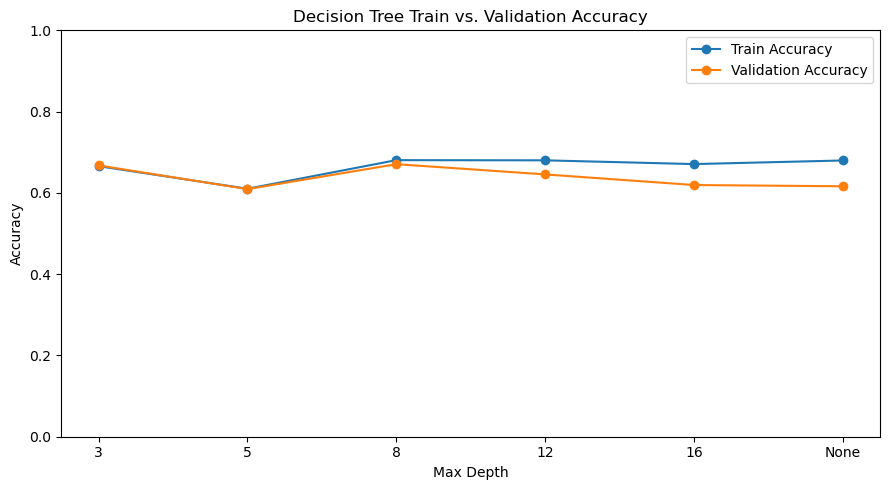

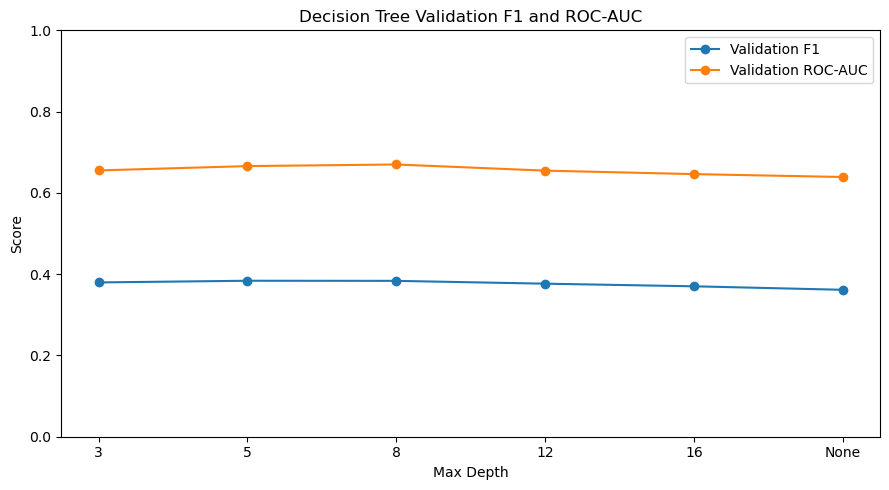

In [28]:
tree_plot_df = tree_results_df.copy()
tree_plot_df["Max Depth"] = tree_plot_df["Max Depth"].astype(str)

plt.figure(figsize=(9, 5))
plt.plot(tree_plot_df["Max Depth"], tree_plot_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(tree_plot_df["Max Depth"], tree_plot_df["Validation Accuracy"], marker="o", label="Validation Accuracy")
plt.title("Decision Tree Train vs. Validation Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(tree_plot_df["Max Depth"], tree_plot_df["Validation F1"], marker="o", label="Validation F1")
plt.plot(tree_plot_df["Max Depth"], tree_plot_df["Validation ROC-AUC"], marker="o", label="Validation ROC-AUC")
plt.title("Decision Tree Validation F1 and ROC-AUC")
plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()


## 8. Random forest model

A random forest combines many decision trees. This usually performs better than one tree because it reduces the risk of relying too much on one specific tree structure.

The random forest can also give feature importance values, which helps explain which predictors mattered most.

In [29]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,
        max_depth=16,
        min_samples_leaf=25,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=-1
    ))
])

random_forest.fit(X_train, y_train)

pred_rf_train = random_forest.predict(X_train)
pred_rf_valid = random_forest.predict(X_valid)
prob_rf_valid = random_forest.predict_proba(X_valid)[:, 1]

print("Random Forest")
print("Training Accuracy:", round(accuracy_score(y_train, pred_rf_train), 4))
print("Validation Accuracy:", round(accuracy_score(y_valid, pred_rf_valid), 4))
print("Validation Precision:", round(precision_score(y_valid, pred_rf_valid), 4))
print("Validation Recall:", round(recall_score(y_valid, pred_rf_valid), 4))
print("Validation F1:", round(f1_score(y_valid, pred_rf_valid), 4))
print("Validation ROC-AUC:", round(roc_auc_score(y_valid, prob_rf_valid), 4))

print("\nClassification report:")
print(classification_report(y_valid, pred_rf_valid))


Random Forest
Training Accuracy: 0.7365
Validation Accuracy: 0.692
Validation Precision: 0.3232
Validation Recall: 0.5691
Validation F1: 0.4122
Validation ROC-AUC: 0.705

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.72      0.79     20256
           1       0.32      0.57      0.41      4744

    accuracy                           0.69     25000
   macro avg       0.60      0.64      0.60     25000
weighted avg       0.77      0.69      0.72     25000



## 9. Compare models

This table compares the best single-tree model to the random forest. It also includes the deep tree to show why overfitting matters.

In [30]:
best_tree_row = tree_results_df.sort_values("Validation F1", ascending=False).iloc[0]
best_depth = None if best_tree_row["Max Depth"] == "None" else int(best_tree_row["Max Depth"])

best_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_leaf=50,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

best_tree.fit(X_train, y_train)
pred_best_tree = best_tree.predict(X_valid)
prob_best_tree = best_tree.predict_proba(X_valid)[:, 1]

model_comparison = pd.DataFrame([
    {
        "Model": "Deep Decision Tree",
        "Accuracy": accuracy_score(y_valid, pred_deep_valid),
        "Precision": precision_score(y_valid, pred_deep_valid),
        "Recall": recall_score(y_valid, pred_deep_valid),
        "F1": f1_score(y_valid, pred_deep_valid),
        "ROC-AUC": roc_auc_score(y_valid, prob_deep_valid)
    },
    {
        "Model": f"Best Tuned Tree, depth={best_tree_row['Max Depth']}",
        "Accuracy": accuracy_score(y_valid, pred_best_tree),
        "Precision": precision_score(y_valid, pred_best_tree),
        "Recall": recall_score(y_valid, pred_best_tree),
        "F1": f1_score(y_valid, pred_best_tree),
        "ROC-AUC": roc_auc_score(y_valid, prob_best_tree)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_valid, pred_rf_valid),
        "Precision": precision_score(y_valid, pred_rf_valid),
        "Recall": recall_score(y_valid, pred_rf_valid),
        "F1": f1_score(y_valid, pred_rf_valid),
        "ROC-AUC": roc_auc_score(y_valid, prob_rf_valid)
    }
])

model_comparison


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Deep Decision Tree,0.72180,0.270691,0.275084,0.272870,0.550753
1,"Best Tuned Tree, depth=5",0.60928,0.273857,0.641231,0.383800,0.665928
2,Random Forest,0.69204,0.323160,0.569140,0.412245,0.704976


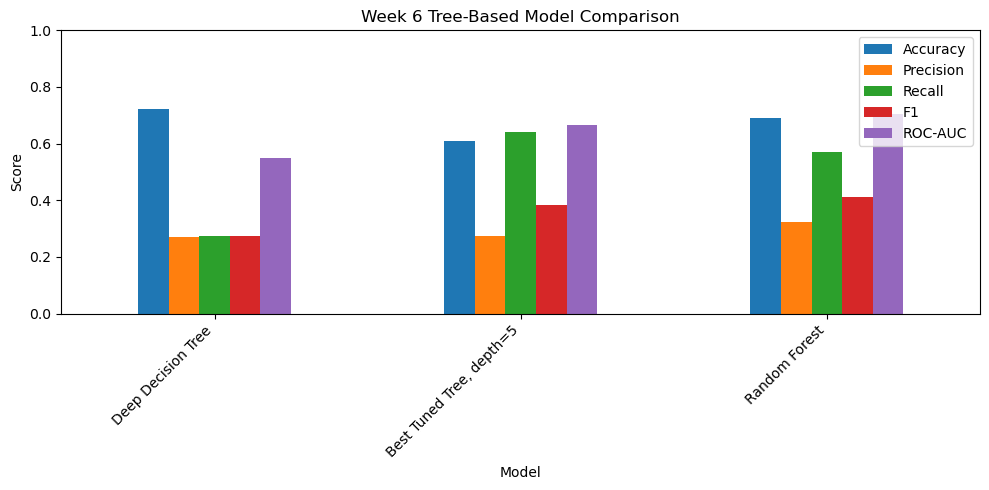

In [31]:
model_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Week 6 Tree-Based Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 10. Confusion matrix for random forest

The confusion matrix shows how many delayed and non-delayed flights the random forest classified correctly or incorrectly.

In [32]:
cm = confusion_matrix(y_valid, pred_rf_valid)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Delayed", "Actual Delayed"],
    columns=["Predicted Not Delayed", "Predicted Delayed"]
)

cm_df


,Predicted Not Delayed,Predicted Delayed
Actual Not Delayed,14601,5655
Actual Delayed,2044,2700


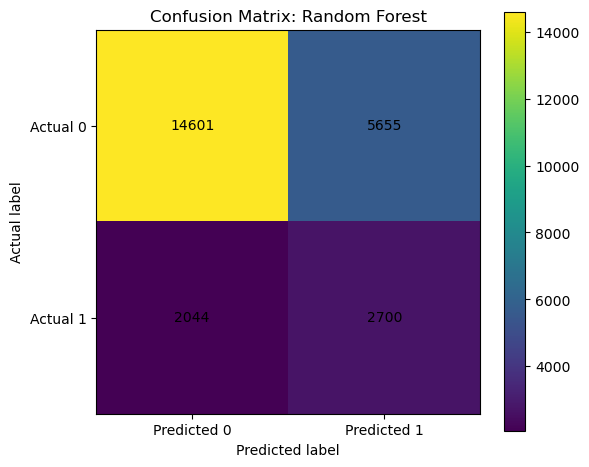

In [33]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix: Random Forest")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Predicted 0", "Predicted 1"])
plt.yticks(tick_marks, ["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


## 11. ROC curve for random forest

The ROC curve shows how well the random forest separates delayed and non-delayed flights across different thresholds.

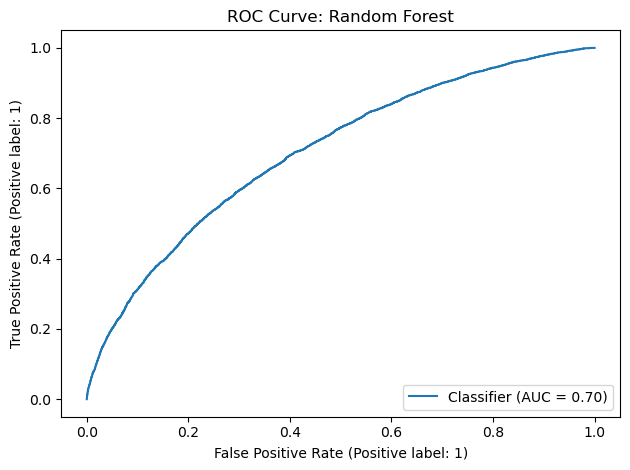

In [34]:
RocCurveDisplay.from_predictions(y_valid, prob_rf_valid)
plt.title("ROC Curve: Random Forest")
plt.tight_layout()
plt.show()


## 12. Feature importance

Random forests provide feature importance scores. These scores help show which predictors were most useful for splitting the data.

This is important for the final project because the goal is not only to predict delays, but also to explain which operational factors appear most important.

In [35]:
# Get feature names and random forest importances

preprocessor_fitted = random_forest.named_steps["preprocessor"]
rf_model = random_forest.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

importance_df.head(20)


,Feature,Importance
24,num__DEP_BLOCK_HIST,0.144792
22,num__DEP_AIRPORT_HIST,0.070258
16,num__PRCP,0.061903
21,num__CARRIER_HISTORICAL,0.059225
3,num__SEGMENT_NUMBER,0.050444
23,num__DAY_HISTORICAL,0.048893
20,num__AWND,0.039254
6,num__AIRPORT_FLIGHTS_MONTH,0.038088
8,num__AIRLINE_AIRPORT_FLIGHTS_MONTH,0.037206
19,num__TMAX,0.034464


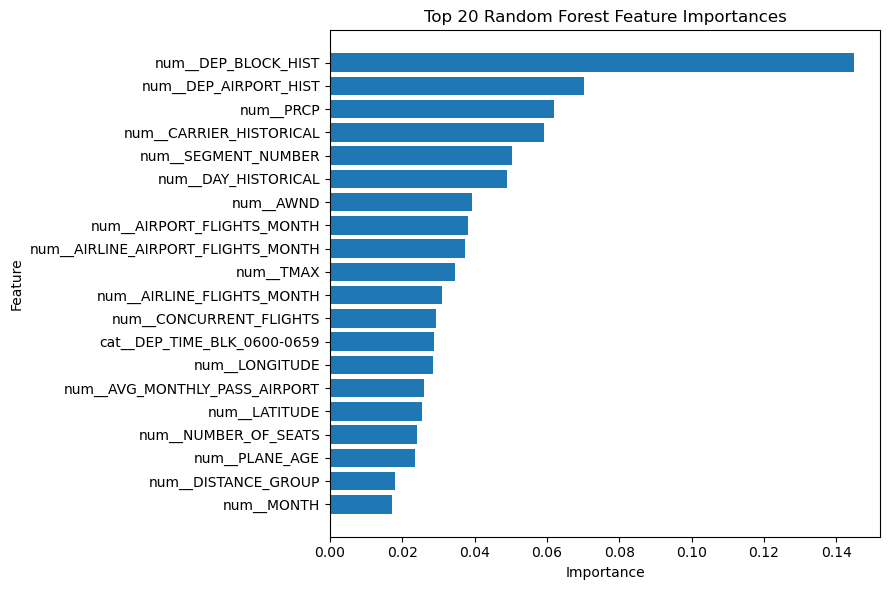

In [36]:
top_importance = importance_df.head(20)

plt.figure(figsize=(9, 6))
plt.barh(top_importance["Feature"], top_importance["Importance"])
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Week 6 Conclusion

In this notebook, I used decision trees and random forests to classify flight delays. The deep decision tree showed a clear overfitting problem because it fit the training data too closely but did not generalize as well to the validation data.

The tuned decision tree improved the results by limiting tree depth. This made the model less complex and helped reduce overfitting. The random forest performed better overall because it combined many trees and reduced the risk of relying too heavily on one overfit tree.

The feature importance results were especially useful because they showed which variables were most connected to delay prediction. Overall, Week 6 showed that tree-based models are a strong option for this dataset because they can handle nonlinear patterns and provide interpretable information about important delay factors.
